## Семинар (практическая работа) 1.3

### Вариант 7

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
n = np.array([100, 500, 1000, 5000, 10000, 50000])
t = np.array([0.055, 0.321, 0.667, 3.894, 8.231, 48.902])

In [3]:
def linear_model(x, a, b):
    return a * x + b

In [4]:
def quadratic_model(x, c, b):
    return c * x**2 + b * x

In [5]:
def log_model(x, a):
    return a * np.log2(x)

#### Подбор параметров

In [6]:
params_lin, _ = curve_fit(linear_model, n, t)
a_lin, b_lin = params_lin
t_lin = linear_model(n, a_lin, b_lin)
sse_lin = np.sum((t - t_lin) ** 2)

In [7]:
params_quad, _ = curve_fit(quadratic_model, n, t)
c_quad, b_quad = params_quad
t_quad = quadratic_model(n, c_quad, b_quad)
sse_quad = np.sum((t - t_quad) ** 2)

In [8]:
params_log, _ = curve_fit(log_model, n, t)
a_log = params_log[0]
t_log = log_model(n, a_log)
sse_log = np.sum((t - t_log) ** 2)

#### Результат подбора моделей сложности

In [10]:
print(f"ЛИНЕЙНАЯ МОДЕЛЬ: T = {a_lin:.6f} * n + {b_lin:.6f}")
print(f"  SSE = {sse_lin:.6f}")

print(f"\nКВАДРАТИЧНАЯ МОДЕЛЬ: T = {c_quad:.3e} * n² + {b_quad:.6f} * n")
print(f"  SSE = {sse_quad:.6f}")

print(f"\nЛОГАРИФМИЧЕСКАЯ МОДЕЛЬ: T = {a_log:.6f} * log2(n)")
print(f"  SSE = {sse_log:.6f}")

ЛИНЕЙНАЯ МОДЕЛЬ: T = 0.000985 * n + -0.588741
  SSE = 1.859660

КВАДРАТИЧНАЯ МОДЕЛЬ: T = 4.042e-09 * n² + 0.000776 * n
  SSE = 301.398545

ЛОГАРИФМИЧЕСКАЯ МОДЕЛЬ: T = 1.170300 * log2(n)
  SSE = 1385.960449


#### Определение лучшей модели по SSE

In [12]:
models = {'Линейная': sse_lin, 'Квадратичная': sse_quad, 'Логарифмическая': sse_log}
best_model = min(models, key=models.get)
print(f"Лучшая модель: {best_model} (SSE = {models[best_model]:.6f})")

Лучшая модель: Линейная (SSE = 1.859660)


#### Таблица сравнения

In [13]:
header = f"{'n':>8} {'Факт, с':>10} {'Линейная':>12} {'Квадратичная':>14} {'Логарифм.':>12}"
print(header)
print("-" * len(header))
for i in range(len(n)):
    print(f"{n[i]:8d} {t[i]:10.3f} {t_lin[i]:12.3f} {t_quad[i]:14.3f} {t_log[i]:12.3f}")
print("-" * len(header))

       n    Факт, с     Линейная   Квадратичная    Логарифм.
------------------------------------------------------------
     100      0.055       -0.490          0.078        7.775
     500      0.321       -0.096          0.389       10.493
    1000      0.667        0.396          0.780       11.663
    5000      3.894        4.336          3.981       14.380
   10000      8.231        9.261          8.164       15.551
   50000     48.902       48.662         31.542       18.268
------------------------------------------------------------


#### График

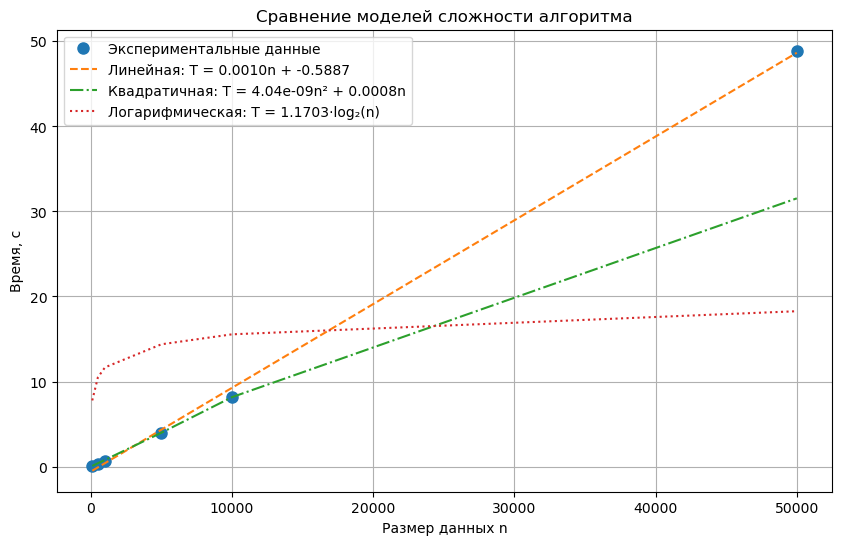

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(n, t, 'o', label='Экспериментальные данные', markersize=8)
plt.plot(n, t_lin, '--', label=f'Линейная: T = {a_lin:.4f}n + {b_lin:.4f}')
plt.plot(n, t_quad, '-.', label=f'Квадратичная: T = {c_quad:.2e}n² + {b_quad:.4f}n')
plt.plot(n, t_log, ':', label=f'Логарифмическая: T = {a_log:.4f}·log₂(n)')
plt.xlabel('Размер данных n')
plt.ylabel('Время, с')
plt.title('Сравнение моделей сложности алгоритма')
plt.legend()
plt.grid(True)
plt.show()